# Sales level shift — robustezza alla contaminazione normal-only

Questo notebook valuta quanto la pipeline forecasting-based per il caso `level_shift` sia sensibile alla contaminazione dei dati trattati come normali.

La logica sperimentale è la seguente:

1. per ogni livello di contaminazione si costruiscono modello e soglie usando solo train e validation del livello corrispondente;
2. le soglie sono calibrate sulla validation tramite `double_mad`, quindi con una stima robusta e asimmetrica della dispersione dello score;
3. la valutazione finale usa sempre gli stessi sensitivity dataset di test.

Il test non viene modificato: le differenze nelle metriche dipendono solo dal modello e dalle soglie ottenute dai dati trattati come normali.

In [1]:
# =========================================================
# PATH
# =========================================================

import sys
from pathlib import Path

start_dir = Path.cwd().resolve()

for candidate in [start_dir, *start_dir.parents]:
    if (candidate / "project_paths.py").is_file():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError(
        "Root del progetto non trovata. "
        "Avvia Jupyter da una cartella interna alla repository."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
# =========================================================
# IMPORTS
# =========================================================

import json
import pickle
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from IPython.display import display

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping

from project_paths import (
    LEVEL_SHIFT_CONTAMINATION_DIR,
    LEVEL_SHIFT_RESULTS_DIR,
    LEVEL_SHIFT_SENSITIVITY_DIR,
    SALES_MODEL_DIR,
    ensure_artifact_directories,
)

ensure_artifact_directories()

from sales_level_shift_utils import (
    list_sensitivity_datasets,
    add_level_shift_score,
    detect_level_shift_from_score_by_store,
    build_detected_windows_from_center_points,
    build_gt_level_shift_windows,
    evaluate_detected_windows_event_level,
    normalize_sales_feature_schema,
    build_sales_dataset_train_val_from_template,
    build_sales_dataset_inference_from_template,
    build_sales_model_inputs_from_features,
    build_lstm_sales_model_from_features,
    make_sales_results_from_features,
    infer_model_window_size,
    compute_level_shift_double_mad_thresholds_by_store,
    double_mad_thresholds_to_dataframe,
    classify_level_shift_severity,
)

## Configurazione

Questa sezione definisce path, cache, architettura del modello, parametri di training e configurazione del detector.

L'esperimento mantiene fissa la pipeline di detection e varia solo il livello di contaminazione dei dati normal-only. Le soglie sono calibrate con `double_mad`, cioè una versione robusta basata su mediana e MAD separata per lato inferiore e superiore della distribuzione degli score.

I flag di recompute separano tre operazioni: riaddestramento dei modelli, ricalcolo delle soglie e rivalutazione dei sensitivity dataset.

In [3]:
# =========================================================
# CONFIG
# =========================================================

CONTAMINATION_PATH = LEVEL_SHIFT_CONTAMINATION_DIR
BASE_SENSITIVITY_PATH = LEVEL_SHIFT_SENSITIVITY_DIR

OUTPUT_DIR = LEVEL_SHIFT_RESULTS_DIR / "contamination_robustness"
MODEL_CACHE_DIR = OUTPUT_DIR / "_model_cache_sales_tuning_small_double_mad_code_levels_v3"
EVAL_CACHE_DIR = OUTPUT_DIR / "_eval_cache_double_mad_sales_tuning_small_code_levels_v3"
TABLES_DIR = OUTPUT_DIR / "tables"
FIGURES_DIR = OUTPUT_DIR / "figures"

# Le cache sono separate tra artifact di training e valutazioni sui dataset sensitivity.
for path in [OUTPUT_DIR, MODEL_CACHE_DIR, EVAL_CACHE_DIR, TABLES_DIR, FIGURES_DIR]:
    path.mkdir(parents=True, exist_ok=True)

# Codici interi in decimi di punto percentuale:
# 0 -> 0%, 5 -> 0.5%, 10 -> 1%, 20 -> 2%, 30 -> 3%, 50 -> 5%.
CONTAMINATION_LEVELS = [0, 5, 10, 20, 30, 50]

# Training con early stopping sulla validation del livello corrente.
TRAIN_SIZE = 0.70
VAL_SIZE = 0.10
EPOCHS = 200
BATCH_SIZE = 64
PATIENCE = 25
RANDOM_SEED = 42

# -------------------------
# Detector level shift finale
# -------------------------
SCORE_WINDOW = 7
THRESHOLD_METHOD = "double_mad"
THRESHOLD_MULTIPLIER = 3.5
MAD_NORMAL_CONSISTENCY_FACTOR = 1.4826
MIN_CONSECUTIVE = 3
GAP_TOLERANCE = 1
IOU_THRESHOLD = 0.20

# -------------------------
# Cache / recompute
# -------------------------
# Se True, riaddestra i modelli LSTM anche se sono già salvati.
FORCE_RECOMPUTE_MODELS = False

# Se True, ricalcola le soglie MAD dai val_results anche se sono già salvate.
FORCE_RECOMPUTE_THRESHOLDS = False

# Se True, rivaluta tutti i sensitivity dataset anche se esistono cache/raw results.
# I modelli già addestrati vengono comunque riusati se FORCE_RECOMPUTE_MODELS=False.
FORCE_RECOMPUTE_EVALUATION = False

DEBUG_MAX_DATASETS = None

# Modello sales finale: usato direttamente per il livello 0%.

SELECTED_MODEL_DIR = SALES_MODEL_DIR

SELECTED_MODEL_PATH = SELECTED_MODEL_DIR / "lstm_sales.keras"
SELECTED_FEATURE_SCALERS_PATH = SELECTED_MODEL_DIR / "feature_scalers.pkl"
SELECTED_MAPPINGS_PATH = SELECTED_MODEL_DIR / "mappings.pkl"
SELECTED_FEATURES_PATH = SELECTED_MODEL_DIR / "features.pkl"

# Questi possono anche non esistere in models/sales: il codice già gestisce fallback.
SELECTED_HISTORY_PATH = SELECTED_MODEL_DIR / "history.pkl"
SELECTED_CONFIG_PATH = SELECTED_MODEL_DIR / "training_config.pkl"

USE_SELECTED_MODEL_FOR_LEVEL_ZERO = True


def load_selected_training_config():
    if SELECTED_CONFIG_PATH.exists():
        with open(SELECTED_CONFIG_PATH, "rb") as f:
            return pickle.load(f)
    return {}


SELECTED_TRAINING_CONFIG = load_selected_training_config()

# La finestra è ricavata dal modello promosso per evitare disallineamenti
# con gli artifact di preprocessing. Gli altri parametri usano la configurazione
# promossa e mantengono i valori precedenti come fallback.
if SELECTED_MODEL_PATH.exists():
    _selected_model = tf.keras.models.load_model(SELECTED_MODEL_PATH)
    MODEL_WINDOW_SIZE = infer_model_window_size(_selected_model)
    del _selected_model
else:
    MODEL_WINDOW_SIZE = int(SELECTED_TRAINING_CONFIG.get("window_size", 28))

ARCHITECTURE_NAME = str(
    SELECTED_TRAINING_CONFIG.get("architecture_name", "small")
)
LSTM_UNITS = int(SELECTED_TRAINING_CONFIG.get("lstm_units", 32))
SEQ_DENSE_UNITS = int(
    SELECTED_TRAINING_CONFIG.get("seq_dense_units", 16)
)
DENSE_1_UNITS = int(
    SELECTED_TRAINING_CONFIG.get("dense_1_units", 32)
)
DENSE_2_UNITS = int(
    SELECTED_TRAINING_CONFIG.get("dense_2_units", 16)
)
DROPOUT_RATE = float(
    SELECTED_TRAINING_CONFIG.get("dropout_rate", 0.025)
)
LEARNING_RATE = float(
    SELECTED_TRAINING_CONFIG.get("learning_rate", 5e-4)
)

RAW_RESULTS_PATH = OUTPUT_DIR / "level_shift_contamination_robustness_raw_double_mad_code_levels.csv"
POOLED_SUMMARY_PATH = TABLES_DIR / "level_shift_contamination_robustness_pooled_double_mad_code_levels.csv"
THRESHOLD_SUMMARY_PATH = TABLES_DIR / "level_shift_contamination_threshold_summary_double_mad_code_levels.csv"
TRAINING_SUMMARY_PATH = TABLES_DIR / "level_shift_contamination_training_summary_double_mad_code_levels.csv"

CONFIG = {
    "CONTAMINATION_LEVELS": CONTAMINATION_LEVELS,
    "MODEL_WINDOW_SIZE": MODEL_WINDOW_SIZE,
    "architecture_name": ARCHITECTURE_NAME,
    "lstm_units": LSTM_UNITS,
    "seq_dense_units": SEQ_DENSE_UNITS,
    "dense_1_units": DENSE_1_UNITS,
    "dense_2_units": DENSE_2_UNITS,
    "dropout_rate": DROPOUT_RATE,
    "learning_rate": LEARNING_RATE,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "patience": PATIENCE,
    "score_window": SCORE_WINDOW,
    "threshold_method": THRESHOLD_METHOD,
    "threshold_multiplier": THRESHOLD_MULTIPLIER,
    "mad_normal_consistency_factor": MAD_NORMAL_CONSISTENCY_FACTOR,
    "min_consecutive": MIN_CONSECUTIVE,
    "gap_tolerance": GAP_TOLERANCE,
    "iou_threshold": IOU_THRESHOLD,
    "force_recompute_models": FORCE_RECOMPUTE_MODELS,
    "force_recompute_thresholds": FORCE_RECOMPUTE_THRESHOLDS,
    "force_recompute_evaluation": FORCE_RECOMPUTE_EVALUATION,
    "selected_model_dir": str(SELECTED_MODEL_DIR),
    "selected_model_path": str(SELECTED_MODEL_PATH),
    "use_selected_model_for_level_zero": USE_SELECTED_MODEL_FOR_LEVEL_ZERO,
}

print("CONTAMINATION_PATH:", CONTAMINATION_PATH)
print("BASE_SENSITIVITY_PATH:", BASE_SENSITIVITY_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR)
CONFIG


def selected_tuning_artifacts_exist():
    required = [
        SELECTED_MODEL_PATH,
        SELECTED_FEATURE_SCALERS_PATH,
        SELECTED_MAPPINGS_PATH,
        SELECTED_FEATURES_PATH,
    ]
    return all(path.exists() for path in required)


def load_selected_features_template():
    if SELECTED_FEATURES_PATH.exists():
        with open(SELECTED_FEATURES_PATH, "rb") as f:
            return pickle.load(f)
    return None


SELECTED_FEATURES_TEMPLATE = load_selected_features_template()

CONTAMINATION_PATH: C:\Users\ciok4\jupyter file\tesi\artifacts\data\datasets\level_shift\contamination
BASE_SENSITIVITY_PATH: C:\Users\ciok4\jupyter file\tesi\artifacts\data\datasets\level_shift\sensitivity
OUTPUT_DIR: C:\Users\ciok4\jupyter file\tesi\artifacts\results\level_shift\contamination_robustness


## Dataset contaminati

Ogni livello contiene un dataset multi-store in cui la contaminazione è applicata solo agli split usati come dati normali, cioè train e validation.

Le summary di generazione vengono caricate solo per documentare il livello effettivo raggiunto: non sono usate né per addestrare il modello né per calibrare il detector.

In [4]:
# =========================================================
# CONTAMINATION DATASET INDEX
# =========================================================

def build_contamination_dataset_index(base_path, contamination_levels):
    base_path = Path(base_path)
    rows = []

    for level in contamination_levels:
        level_dir = base_path / f"contamination_{int(level)}"
        dataset_path = level_dir / "all_stores_cashflow.csv"
        summary_path = level_dir / "contamination_summary.csv"
        type_summary_path = level_dir / "contamination_type_summary.csv"
        config_path = level_dir / "config.json"

        rows.append({
            "contamination_level": int(level),
            "contamination_percent": int(level) / 10.0,
            "contamination_fraction": int(level) / 1000.0,
            "level_dir": level_dir,
            "dataset_path": dataset_path,
            "summary_path": summary_path,
            "type_summary_path": type_summary_path,
            "config_path": config_path,
            "dataset_exists": dataset_path.exists(),
            "summary_exists": summary_path.exists(),
            "type_summary_exists": type_summary_path.exists(),
        })

    return pd.DataFrame(rows)


contamination_index = build_contamination_dataset_index(
    CONTAMINATION_PATH,
    CONTAMINATION_LEVELS,
)

missing = contamination_index[~contamination_index["dataset_exists"]]

if not missing.empty:
    display(contamination_index)
    raise FileNotFoundError(
        "Mancano alcuni dataset di contaminazione. "
        "Eseguire prima la funzione di generazione in data_generation.py."
    )

contamination_index

,contamination_level,contamination_percent,contamination_fraction,level_dir,dataset_path,summary_path,type_summary_path,config_path,dataset_exists,summary_exists,type_summary_exists
0,0,0.0,0.000,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,True,True,True
1,5,0.5,0.005,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,True,True,True
2,10,1.0,0.010,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,True,True,True
3,20,2.0,0.020,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,True,True,True
4,30,3.0,0.030,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,True,True,True
5,50,5.0,0.050,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,True,True,True


In [5]:
# =========================================================
# LOAD CONTAMINATION GENERATION SUMMARY
# =========================================================

def load_contamination_summaries(contamination_index):
    summary_parts = []
    type_summary_parts = []

    for _, row in contamination_index.iterrows():
        level = int(row["contamination_level"])

        if row["summary_path"].exists():
            s = pd.read_csv(row["summary_path"])
            s["contamination_level"] = level
            s["contamination_percent"] = int(level) / 10.0
            summary_parts.append(s)

        if row["type_summary_path"].exists():
            ts = pd.read_csv(row["type_summary_path"])
            ts["contamination_level"] = level
            ts["contamination_percent"] = int(level) / 10.0
            type_summary_parts.append(ts)

    summary = (
        pd.concat(summary_parts, ignore_index=True)
        if summary_parts
        else pd.DataFrame()
    )

    type_summary = (
        pd.concat(type_summary_parts, ignore_index=True)
        if type_summary_parts
        else pd.DataFrame()
    )

    return summary, type_summary


contamination_generation_summary, contamination_type_summary = load_contamination_summaries(
    contamination_index
)

if not contamination_generation_summary.empty:
    display(
        contamination_generation_summary[
            [
                "contamination_level",
                "contamination_percent",
                "split",
                "target_fraction",
                "actual_fraction",
                "n_days",
                "target_anomaly_days",
                "actual_anomaly_days",
                "n_events",
                "n_affected_stores",
            ]
        ].sort_values(["contamination_level", "split"])
    )
else:
    print("Summary di generazione non disponibile.")

if not contamination_type_summary.empty:
    display(contamination_type_summary.head(20))

,contamination_level,contamination_percent,split,target_fraction,actual_fraction,n_days,target_anomaly_days,actual_anomaly_days,n_events,n_affected_stores
0,0,0.0,train,0.000,0.000000,17890,0,0,0,0
1,0,0.0,val,0.000,0.000000,2560,0,0,0,0
2,5,0.5,train,0.005,0.004751,17890,89,85,8,5
3,5,0.5,val,0.005,0.005078,2560,13,13,1,1
4,10,1.0,train,0.010,0.009726,17890,179,174,17,9
5,10,1.0,val,0.010,0.008594,2560,26,22,2,2
6,20,2.0,train,0.020,0.020067,17890,358,359,34,10
7,20,2.0,val,0.020,0.018750,2560,51,48,4,4
8,30,3.0,train,0.030,0.030184,17890,537,540,52,10
9,30,3.0,val,0.030,0.027734,2560,77,71,6,5


,split,contamination_level,target_fraction,lsa_type,anomaly_days,anomaly_day_share,n_events,contamination_percent
0,train,0,0.000,soft_increase,0,0.000000,0,0.0
1,train,0,0.000,hard_increase,0,0.000000,0,0.0
2,train,0,0.000,soft_decrease,0,0.000000,0,0.0
3,train,0,0.000,hard_decrease,0,0.000000,0,0.0
4,val,0,0.000,soft_increase,0,0.000000,0,0.0
5,val,0,0.000,hard_increase,0,0.000000,0,0.0
6,val,0,0.000,soft_decrease,0,0.000000,0,0.0
7,val,0,0.000,hard_decrease,0,0.000000,0,0.0
8,train,5,0.005,soft_increase,21,0.247059,2,0.5
9,train,5,0.005,hard_increase,21,0.247059,2,0.5


## Dataset di test

I sensitivity dataset costituiscono il benchmark comune di valutazione.

Sono mantenuti identici per tutti i livelli di contaminazione, così il confronto misura esclusivamente l'effetto della contaminazione su modello e soglie, non una variazione del test set.

In [6]:
# =========================================================
# LIST SENSITIVITY DATASETS
# =========================================================

if not BASE_SENSITIVITY_PATH.exists():
    raise FileNotFoundError(f"Cartella sensitivity non trovata: {BASE_SENSITIVITY_PATH}")

datasets_df = list_sensitivity_datasets(BASE_SENSITIVITY_PATH)
datasets_df = datasets_df.sort_values(
    ["direction", "duration", "multiplier", "seed"]
).reset_index(drop=True)

if DEBUG_MAX_DATASETS is not None:
    datasets_df = datasets_df.head(DEBUG_MAX_DATASETS).copy()

print("Numero dataset sensitivity:", len(datasets_df))
display(datasets_df.head())

display(
    datasets_df
    .groupby(["direction", "duration", "multiplier"])
    .size()
    .rename("n_seeds")
    .reset_index()
    .head(20)
)

Numero dataset sensitivity: 280


,path,direction,duration,multiplier,seed
0,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,decrease,7,0.7,42
1,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,decrease,7,0.7,43
2,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,decrease,7,0.7,44
3,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,decrease,7,0.7,45
4,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,decrease,7,0.7,46


,direction,duration,multiplier,n_seeds
0,decrease,7,0.700,5
1,decrease,7,0.800,5
2,decrease,7,0.850,5
3,decrease,7,0.900,5
4,decrease,7,0.925,5
5,decrease,7,0.950,5
6,decrease,7,0.975,5
7,decrease,10,0.700,5
8,decrease,10,0.800,5
9,decrease,10,0.850,5


## Preprocessing e costruzione del modello

Le utility per feature engineering, encoding, scaling, sequenze e costruzione
del modello LSTM sono centralizzate in `sales_level_shift_utils.py`.

Le colonne di ground truth vengono conservate solo per la valutazione finale.
Non entrano tra gli input del modello.

## Schema LSTM sales adattivo

Le utility condivise supportano entrambi gli schemi apparsi nei notebook sales:

- schema legacy: `holiday`, `actual_holiday` e `pre_holiday` tra le categoriche finali;
- schema aggiornato: booleane finali in `X_final_bool` e categoriche finali solo
  `store_id`, `week_day`, `month` e `day`.

Il livello `0\%` usa quindi esattamente input e preprocessing del modello selezionato,
mentre i livelli contaminati vengono riaddestrati con lo stesso schema feature.

## Training e calibrazione per livello

Per ogni livello di contaminazione vengono preparati gli artefatti necessari alla valutazione:

- modello LSTM e oggetti di preprocessing;
- risultati di validation;
- soglie store-specific calibrate con `double_mad`;
- summary di training e di calibrazione.

La cache consente di riusare modelli e soglie già calcolati quando si vuole aggiornare solo una parte dell'esperimento.

In [7]:
# =========================================================
# MODEL CACHE HELPERS
# =========================================================

def get_level_model_dir(contamination_level):
    level_dir = MODEL_CACHE_DIR / f"level_{int(contamination_level)}"
    level_dir.mkdir(parents=True, exist_ok=True)
    return level_dir


def get_required_level_paths(contamination_level):
    level_dir = get_level_model_dir(contamination_level)

    return {
        "level_dir": level_dir,
        "model": level_dir / "lstm_sales_contamination.keras",
        "feature_scalers": level_dir / "feature_scalers.pkl",
        "mappings": level_dir / "mappings.pkl",
        "features": level_dir / "features.pkl",
        "history": level_dir / "history.pkl",
        "training_summary": level_dir / "training_summary.json",
        "val_results": level_dir / "val_results.pkl",

        # File separati per la calibrazione MAD, così non si riusano soglie STD vecchie.
        "thresholds": level_dir / "thresholds_double_mad.pkl",
        "threshold_summary": level_dir / "threshold_summary_double_mad.csv",
    }


def model_artifacts_exist(contamination_level):
    paths = get_required_level_paths(contamination_level)

    required = [
        paths["model"],
        paths["feature_scalers"],
        paths["mappings"],
        paths["features"],
        paths["history"],
        paths["training_summary"],
        paths["val_results"],
    ]

    return all(path.exists() for path in required)


def threshold_artifacts_exist(contamination_level):
    paths = get_required_level_paths(contamination_level)

    required = [
        paths["thresholds"],
        paths["threshold_summary"],
    ]

    return all(path.exists() for path in required)

In [8]:
# =========================================================
# TRAIN OR LOAD LEVEL MODEL
# =========================================================

def load_cached_model_artifacts(contamination_level):
    paths = get_required_level_paths(contamination_level)

    model = tf.keras.models.load_model(paths["model"])

    with open(paths["feature_scalers"], "rb") as f:
        feature_scalers = pickle.load(f)

    with open(paths["mappings"], "rb") as f:
        mappings = pickle.load(f)

    with open(paths["features"], "rb") as f:
        features = pickle.load(f)

    with open(paths["history"], "rb") as f:
        history_dict = pickle.load(f)

    with open(paths["training_summary"], "r", encoding="utf-8") as f:
        training_summary = json.load(f)

    with open(paths["val_results"], "rb") as f:
        val_results = pickle.load(f)

    return {
        "model": model,
        "feature_scalers": feature_scalers,
        "mappings": mappings,
        "features": features,
        "history": history_dict,
        "training_summary": training_summary,
        "val_results": val_results,
    }




def import_selected_level_zero_artifacts(dataset_path):
    """
    Importa il modello già selezionato dal tuning sales per il livello 0%.
    Non viene eseguito nessun retraining: si calcolano solo validation results
    e soglie MAD coerenti con la pipeline contamination.
    """
    if not selected_tuning_artifacts_exist():
        missing = [
            str(path) for path in [
                SELECTED_MODEL_PATH,
                SELECTED_FEATURE_SCALERS_PATH,
                SELECTED_MAPPINGS_PATH,
                SELECTED_FEATURES_PATH,
            ]
            if not path.exists()
        ]
        raise FileNotFoundError(
            "Artefatti del modello selezionato non trovati. Mancano: "
            + ", ".join(missing)
        )

    print("\n>>> Livello 0%: importo il modello sales selezionato dal tuning")

    model = tf.keras.models.load_model(SELECTED_MODEL_PATH)

    with open(SELECTED_FEATURE_SCALERS_PATH, "rb") as f:
        feature_scalers = pickle.load(f)

    with open(SELECTED_MAPPINGS_PATH, "rb") as f:
        mappings = pickle.load(f)

    with open(SELECTED_FEATURES_PATH, "rb") as f:
        features = normalize_sales_feature_schema(pickle.load(f))

    if SELECTED_HISTORY_PATH.exists():
        with open(SELECTED_HISTORY_PATH, "rb") as f:
            history_dict = pickle.load(f)
    else:
        history_dict = {}

    selected_config = SELECTED_TRAINING_CONFIG.copy()

    # Il livello 0% riusa il modello selezionato, senza riaddestramento.

    df = pd.read_csv(dataset_path)
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values(["store_id", "date"]).reset_index(drop=True)

    train, val, _ = build_sales_dataset_inference_from_template(
        df,
        feature_scalers=feature_scalers,
        mappings=mappings,
        features=features,
        window_size=MODEL_WINDOW_SIZE,
        train_size=TRAIN_SIZE,
        val_size=VAL_SIZE,
    )

    val_pred = model.predict(
        build_sales_model_inputs_from_features(val, features),
        verbose=0,
    )

    val_results = make_sales_results_from_features(
        val,
        val_pred,
        features,
        feature_scalers,
    )

    val_results = add_level_shift_score(
        val_results,
        window=SCORE_WINDOW,
    )

    n_val_contaminated = (
        int(val_results["is_level_shift_contamination"].sum())
        if "is_level_shift_contamination" in val_results.columns
        else 0
    )

    val_loss = np.nan
    if len(history_dict.get("val_loss", [])) > 0:
        val_loss = float(np.min(history_dict["val_loss"]))

    training_summary = {
        "contamination_level": 0,
        "dataset_path": str(dataset_path),
        "imported_selected_model": True,
        "selected_model_path": str(SELECTED_MODEL_PATH),
        "selected_model_dir": str(SELECTED_MODEL_DIR),
        "architecture_name": selected_config.get("architecture_name", ARCHITECTURE_NAME),
        "model_window_size": int(MODEL_WINDOW_SIZE),
        "lstm_units": int(selected_config.get("lstm_units", LSTM_UNITS)),
        "seq_dense_units": int(selected_config.get("seq_dense_units", SEQ_DENSE_UNITS)),
        "dense_1_units": int(selected_config.get("dense_1_units", DENSE_1_UNITS)),
        "dense_2_units": int(selected_config.get("dense_2_units", DENSE_2_UNITS)),
        "dropout_rate": float(selected_config.get("dropout_rate", DROPOUT_RATE)),
        "learning_rate": float(selected_config.get("learning_rate", LEARNING_RATE)),
        "n_train_sequences": int(len(train["y"])),
        "n_val_sequences": int(len(val["y"])),
        "best_epoch": int(selected_config.get("best_epoch", -1)) if selected_config else -1,
        "best_val_loss": val_loss,
        "last_train_loss": float(history_dict["loss"][-1]) if len(history_dict.get("loss", [])) > 0 else np.nan,
        "last_val_loss": float(history_dict["val_loss"][-1]) if len(history_dict.get("val_loss", [])) > 0 else np.nan,
        "n_val_contaminated_sequences": n_val_contaminated,
    }

    paths = get_required_level_paths(0)

    model.save(paths["model"])

    with open(paths["feature_scalers"], "wb") as f:
        pickle.dump(feature_scalers, f)

    with open(paths["mappings"], "wb") as f:
        pickle.dump(mappings, f)

    with open(paths["features"], "wb") as f:
        pickle.dump(features, f)

    with open(paths["history"], "wb") as f:
        pickle.dump(history_dict, f)

    with open(paths["training_summary"], "w", encoding="utf-8") as f:
        json.dump(training_summary, f, indent=4)

    with open(paths["val_results"], "wb") as f:
        pickle.dump(val_results, f)

    return {
        "model": model,
        "feature_scalers": feature_scalers,
        "mappings": mappings,
        "features": features,
        "history": history_dict,
        "training_summary": training_summary,
        "val_results": val_results,
    }

def train_level_model_artifacts(contamination_level, dataset_path):
    print(f"\n>>> Training livello contaminazione {contamination_level / 10:g}%")

    # Seed distinto per livello, ma stabile tra rerun.
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(RANDOM_SEED + contamination_level)

    df = pd.read_csv(dataset_path)
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values(["store_id", "date"]).reset_index(drop=True)

    train, val, feature_scalers, mappings, features = build_sales_dataset_train_val_from_template(
        df,
        feature_template=SELECTED_FEATURES_TEMPLATE,
        window_size=MODEL_WINDOW_SIZE,
        train_size=TRAIN_SIZE,
        val_size=VAL_SIZE,
    )

    model = build_lstm_sales_model_from_features(
        train=train,
        mappings=mappings,
        lstm_units=LSTM_UNITS,
        seq_dense_units=SEQ_DENSE_UNITS,
        dense_1_units=DENSE_1_UNITS,
        dense_2_units=DENSE_2_UNITS,
        dropout_rate=DROPOUT_RATE,
        learning_rate=LEARNING_RATE,
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=PATIENCE,
        restore_best_weights=True,
        mode="min",
        verbose=1,
    )

    history = model.fit(
        build_sales_model_inputs_from_features(train, features),
        train["y"],
        validation_data=(build_sales_model_inputs_from_features(val, features), val["y"]),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop],
        # Mantiene l’ordine temporale delle sequenze durante il training.
        shuffle=False,
        verbose=1,
    )

    history_dict = history.history
    best_epoch = int(np.argmin(history_dict["val_loss"]) + 1)
    best_val_loss = float(np.min(history_dict["val_loss"]))

    val_pred = model.predict(
        build_sales_model_inputs_from_features(val, features),
        verbose=0,
    )

    val_results = make_sales_results_from_features(
        val,
        val_pred,
        features,
        feature_scalers,
    )

    val_results = add_level_shift_score(
        val_results,
        window=SCORE_WINDOW,
    )

    n_val_contaminated = (
        int(val_results["is_level_shift_contamination"].sum())
        if "is_level_shift_contamination" in val_results.columns
        else 0
    )

    training_summary = {
        "contamination_level": contamination_level,
        "dataset_path": str(dataset_path),
        "n_train_sequences": int(len(train["y"])),
        "n_val_sequences": int(len(val["y"])),
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "last_train_loss": float(history_dict["loss"][-1]),
        "last_val_loss": float(history_dict["val_loss"][-1]),
        "n_val_contaminated_sequences": n_val_contaminated,
    }

    paths = get_required_level_paths(contamination_level)

    model.save(paths["model"])

    with open(paths["feature_scalers"], "wb") as f:
        pickle.dump(feature_scalers, f)

    with open(paths["mappings"], "wb") as f:
        pickle.dump(mappings, f)

    with open(paths["features"], "wb") as f:
        pickle.dump(features, f)

    with open(paths["history"], "wb") as f:
        pickle.dump(history_dict, f)

    with open(paths["training_summary"], "w", encoding="utf-8") as f:
        json.dump(training_summary, f, indent=4)

    with open(paths["val_results"], "wb") as f:
        pickle.dump(val_results, f)

    return {
        "model": model,
        "feature_scalers": feature_scalers,
        "mappings": mappings,
        "features": features,
        "history": history_dict,
        "training_summary": training_summary,
        "val_results": val_results,
    }



def compute_or_load_double_mad_threshold_artifacts(
    contamination_level,
    val_results,
    force_recompute=False,
):
    paths = get_required_level_paths(contamination_level)

    # Le soglie dipendono dai risultati validation del singolo livello.
    if threshold_artifacts_exist(contamination_level) and not force_recompute:
        with open(paths["thresholds"], "rb") as f:
            thresholds = pickle.load(f)

        threshold_summary = pd.read_csv(paths["threshold_summary"])
        return thresholds, threshold_summary

    thresholds = compute_level_shift_double_mad_thresholds_by_store(
        val_results,
        score_col="level_shift_score",
        threshold_multiplier=THRESHOLD_MULTIPLIER,
        mad_factor=MAD_NORMAL_CONSISTENCY_FACTOR,
    )

    threshold_summary = double_mad_thresholds_to_dataframe(
        thresholds,
        contamination_level=contamination_level,
        threshold_method=THRESHOLD_METHOD,
        threshold_multiplier=THRESHOLD_MULTIPLIER,
        mad_factor=MAD_NORMAL_CONSISTENCY_FACTOR,
    )

    with open(paths["thresholds"], "wb") as f:
        pickle.dump(thresholds, f)

    threshold_summary.to_csv(paths["threshold_summary"], index=False)

    return thresholds, threshold_summary

def train_or_load_level_artifacts(contamination_level, dataset_path):
    contamination_level = int(contamination_level)

    model_recomputed = False

    # Solo il livello 0% importa il modello definitivo; gli altri vengono riaddestrati.
    if contamination_level == 0 and USE_SELECTED_MODEL_FOR_LEVEL_ZERO:
        if model_artifacts_exist(contamination_level) and not FORCE_RECOMPUTE_MODELS:
            artifacts = load_cached_model_artifacts(contamination_level)
        else:
            artifacts = import_selected_level_zero_artifacts(dataset_path)
            model_recomputed = True

    elif model_artifacts_exist(contamination_level) and not FORCE_RECOMPUTE_MODELS:
        artifacts = load_cached_model_artifacts(contamination_level)
    else:
        artifacts = train_level_model_artifacts(
            contamination_level=contamination_level,
            dataset_path=dataset_path,
        )
        model_recomputed = True

    thresholds, threshold_summary = compute_or_load_double_mad_threshold_artifacts(
        contamination_level=contamination_level,
        val_results=artifacts["val_results"],
        force_recompute=(FORCE_RECOMPUTE_THRESHOLDS or model_recomputed),
    )

    artifacts["thresholds"] = thresholds
    artifacts["threshold_summary"] = threshold_summary

    return artifacts

In [9]:
# =========================================================
# BUILD/CACHE ALL LEVEL ARTIFACTS
# =========================================================

level_artifacts = {}
training_summary_rows = []
threshold_summary_parts = []

start_time = time.time()

# Ogni livello mantiene modello, preprocessing e soglie separati.
for _, row in contamination_index.iterrows():
    level = int(row["contamination_level"])

    artifacts = train_or_load_level_artifacts(
        contamination_level=level,
        dataset_path=row["dataset_path"],
    )

    level_artifacts[level] = artifacts
    training_summary_rows.append(artifacts["training_summary"])
    threshold_summary_parts.append(artifacts["threshold_summary"])

elapsed = time.time() - start_time
print(f"Preparazione modelli/soglie completata in {elapsed / 60:.1f} minuti.")

training_summary_df = pd.DataFrame(training_summary_rows).sort_values("contamination_level")
threshold_summary_all = pd.concat(threshold_summary_parts, ignore_index=True)

training_summary_df.to_csv(TRAINING_SUMMARY_PATH, index=False)
threshold_summary_all.to_csv(THRESHOLD_SUMMARY_PATH, index=False)

display(training_summary_df)
display(threshold_summary_all.head())

Preparazione modelli/soglie completata in 0.0 minuti.


,contamination_level,dataset_path,imported_selected_model,selected_model_path,selected_model_dir,architecture_name,model_window_size,lstm_units,seq_dense_units,dense_1_units,dense_2_units,dropout_rate,learning_rate,n_train_sequences,n_val_sequences,best_epoch,best_val_loss,last_train_loss,last_val_loss,n_val_contaminated_sequences
0,0,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,True,C:\Users\ciok4\jupyter file\tesi\artifacts\mod...,C:\Users\ciok4\jupyter file\tesi\artifacts\mod...,small,28.0,32.0,16.0,32.0,16.0,0.025,0.0005,17610,2280,46,0.156236,0.146647,0.158851,0
1,5,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17610,2280,97,0.161582,0.144767,0.172395,0
2,10,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17610,2280,82,0.163462,0.146530,0.166229,0
3,20,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17610,2280,138,0.162093,0.141039,0.164536,0
4,30,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17610,2280,57,0.165975,0.152790,0.180984,0
5,50,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17610,2280,42,0.171614,0.155806,0.181361,0


,contamination_level,contamination_percent,contamination_fraction,store_id,threshold_method,threshold_multiplier,score_median,lower_mad,upper_mad,global_mad,...,upper_scale,global_scale,mad_factor,used_lower_fallback,used_upper_fallback,lower_threshold,upper_threshold,threshold_half_width,lower_threshold_distance,upper_threshold_distance
0,0,0.0,0.0,0,double_mad,3.5,0.023040,0.340486,0.362035,0.345033,...,0.536753,0.511546,1.4826,False,False,-1.743778,1.901674,1.822726,1.766818,1.878634
1,0,0.0,0.0,1,double_mad,3.5,0.442988,0.464649,0.339703,0.378284,...,0.503644,0.560844,1.4826,False,False,-1.968123,2.205742,2.086933,2.411111,1.762754
2,0,0.0,0.0,2,double_mad,3.5,0.019391,0.438551,0.344033,0.386010,...,0.510063,0.572299,1.4826,False,False,-2.256295,1.804611,2.030453,2.275687,1.785220
3,0,0.0,0.0,3,double_mad,3.5,0.024393,0.465086,0.441636,0.447768,...,0.654770,0.663861,1.4826,False,False,-2.388986,2.316088,2.352537,2.413379,2.291695
4,0,0.0,0.0,4,double_mad,3.5,-0.067647,0.379093,0.372702,0.372702,...,0.552568,0.552568,1.4826,False,False,-2.034799,1.866341,1.950570,1.967153,1.933988


## Valutazione sui sensitivity dataset

Per ogni coppia `contamination_level × sensitivity_dataset` il modello del livello corrente viene applicato al dataset anomalizzato.

La validation del sensitivity dataset non viene usata per ricalibrare le soglie: il detector usa esclusivamente le soglie ottenute dal livello di contaminazione corrispondente.

In [10]:
# =========================================================
# EVALUATION HELPERS
# =========================================================

def standardize_summary_schema(summary):
    summary = dict(summary)

    start_aliases = [
        "mean_detection_det_offset_start",
        "mean_det_offset_start",
        "det_offset_start_mean",
        "mean_detection_delay",
    ]

    end_aliases = [
        "mean_detection_det_offset_end",
        "mean_det_offset_end",
        "det_offset_end_mean",
    ]

    summary["mean_det_offset_start"] = next(
        (summary[c] for c in start_aliases if c in summary),
        np.nan,
    )

    summary["mean_det_offset_end"] = next(
        (summary[c] for c in end_aliases if c in summary),
        np.nan,
    )

    return summary


def make_eval_cache_path(contamination_level, dataset_row):
    level_dir = EVAL_CACHE_DIR / f"level_{int(contamination_level)}"
    level_dir.mkdir(parents=True, exist_ok=True)

    multiplier_str = str(dataset_row["multiplier"]).replace(".", "p")

    filename = (
        f"{dataset_row['direction']}"
        f"_dur_{int(dataset_row['duration'])}"
        f"_mult_{multiplier_str}"
        f"_seed_{int(dataset_row['seed'])}"
        ".pkl"
    )

    return level_dir / filename


def evaluate_sensitivity_dataset_with_level(contamination_level, dataset_row, artifacts):
    df = pd.read_csv(dataset_row["path"])
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values(["store_id", "date"]).reset_index(drop=True)

    # Le soglie restano quelle calibrate sul validation contaminato del livello.
    _, _, test = build_sales_dataset_inference_from_template(
        df,
        feature_scalers=artifacts["feature_scalers"],
        mappings=artifacts["mappings"],
        features=artifacts["features"],
        window_size=MODEL_WINDOW_SIZE,
        train_size=TRAIN_SIZE,
        val_size=VAL_SIZE,
    )

    test_pred = artifacts["model"].predict(
        build_sales_model_inputs_from_features(test, artifacts["features"]),
        verbose=0,
    )

    test_results = make_sales_results_from_features(
        test,
        test_pred,
        artifacts["features"],
        artifacts["feature_scalers"],
    )

    test_results = add_level_shift_score(
        test_results,
        window=SCORE_WINDOW,
    )

    # Applica sul test le soglie già calibrate per questo livello.
    test_results = detect_level_shift_from_score_by_store(
        test_results,
        artifacts["thresholds"],
        score_col="level_shift_score",
    )

    detected_windows = build_detected_windows_from_center_points(
        test_results,
        detected_col="is_level_shift_detected_raw",
        window_size=SCORE_WINDOW,
        min_consecutive=MIN_CONSECUTIVE,
        gap_tolerance=GAP_TOLERANCE,
    )

    gt_windows = build_gt_level_shift_windows(test_results)

    gt_eval, det_eval, summary = evaluate_detected_windows_event_level(
        gt_windows,
        detected_windows,
        iou_threshold=IOU_THRESHOLD,
    )

    summary = standardize_summary_schema(summary)

    summary.update({
        "contamination_level": int(contamination_level),
        "contamination_percent": int(contamination_level) / 10.0,
        "contamination_fraction": int(contamination_level) / 1000.0,
        "direction": dataset_row["direction"],
        "duration": int(dataset_row["duration"]),
        "multiplier": float(dataset_row["multiplier"]),
        "severity_class": classify_level_shift_severity(dataset_row["multiplier"]),
        "seed": int(dataset_row["seed"]),
        "score_window": SCORE_WINDOW,
        "threshold_method": THRESHOLD_METHOD,
        "threshold_multiplier": THRESHOLD_MULTIPLIER,
        "min_consecutive": MIN_CONSECUTIVE,
        "gap_tolerance": GAP_TOLERANCE,
        "iou_threshold": IOU_THRESHOLD,
        "model_window_size": MODEL_WINDOW_SIZE,
        "csv_path": str(dataset_row["path"]),
    })

    return summary

In [11]:
# =========================================================
# RUN EVALUATION
# =========================================================

# Il CSV raw completo ha priorità sulle cache per singola valutazione.
# Durante il debug viene evitato il riuso o il salvataggio di risultati parziali.
use_raw_results_cache = (
    RAW_RESULTS_PATH.exists()
    and not FORCE_RECOMPUTE_EVALUATION
    and DEBUG_MAX_DATASETS is None
)

if use_raw_results_cache:
    print(f"Carico risultati già calcolati: {RAW_RESULTS_PATH}")
    raw_results = pd.read_csv(RAW_RESULTS_PATH)

else:
    rows = []
    start_time = time.time()

    total_runs = len(CONTAMINATION_LEVELS) * len(datasets_df)
    print(f"Run detector totali: {total_runs}")

    for level in tqdm(CONTAMINATION_LEVELS, desc="Contamination levels"):
        artifacts = level_artifacts[int(level)]

        for _, dataset_row in tqdm(
            datasets_df.iterrows(),
            total=len(datasets_df),
            desc=f"level {level / 10:g}%",
            leave=False,
        ):
            cache_path = make_eval_cache_path(level, dataset_row)

            if cache_path.exists() and not FORCE_RECOMPUTE_EVALUATION:
                with open(cache_path, "rb") as f:
                    summary = pickle.load(f)
            else:
                summary = evaluate_sensitivity_dataset_with_level(
                    contamination_level=level,
                    dataset_row=dataset_row,
                    artifacts=artifacts,
                )

                with open(cache_path, "wb") as f:
                    pickle.dump(summary, f)

            rows.append(summary)

    raw_results = pd.DataFrame(rows)

    if DEBUG_MAX_DATASETS is None:
        raw_results.to_csv(RAW_RESULTS_PATH, index=False)

    elapsed = time.time() - start_time
    print(f"Valutazione completata in {elapsed / 60:.1f} minuti.")

print(raw_results.shape)
display(raw_results.head())

Carico risultati già calcolati: C:\Users\ciok4\jupyter file\tesi\artifacts\results\level_shift\contamination_robustness\level_shift_contamination_robustness_raw_double_mad_code_levels.csv
(1680, 29)


,n_gt_events,n_detected_events,tp,fp,fn,precision,recall,f1,mean_iou,mean_detection_det_offset_start,...,severity_class,seed,score_window,threshold_method,threshold_multiplier,min_consecutive,gap_tolerance,iou_threshold,model_window_size,csv_path
0,40,63,40,23,0,0.634921,1.0,0.776699,0.442237,-5.600,...,hard,42,7,double_mad,3.5,3,1,0.2,28,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...
1,40,63,40,23,0,0.634921,1.0,0.776699,0.448670,-5.625,...,hard,43,7,double_mad,3.5,3,1,0.2,28,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...
2,40,70,40,30,0,0.571429,1.0,0.727273,0.453523,-5.725,...,hard,44,7,double_mad,3.5,3,1,0.2,28,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...
3,40,61,40,21,0,0.655738,1.0,0.792079,0.447495,-5.625,...,hard,45,7,double_mad,3.5,3,1,0.2,28,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...
4,40,67,40,27,0,0.597015,1.0,0.747664,0.452218,-5.700,...,hard,46,7,double_mad,3.5,3,1,0.2,28,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...


## Aggregazioni

Le metriche vengono aggregate per livello di contaminazione usando conteggi pooled di `TP`, `FP` e `FN`.

Questa è la tabella principale da usare nel testo della tesi, perché riassume il comportamento complessivo del detector al crescere della contaminazione.

In [12]:
# =========================================================
# AGGREGATION HELPERS
# =========================================================

def safe_div(num, den):
    return num / den if den > 0 else np.nan


def pooled_f1(precision, recall):
    if pd.isna(precision) or pd.isna(recall) or precision + recall == 0:
        return np.nan
    return 2 * precision * recall / (precision + recall)


def aggregate_pooled(df, group_cols):
    work = df.copy()

    required_cols = [
        "tp", "fp", "fn", "n_gt_events", "n_detected_events",
        "precision", "recall", "f1", "mean_iou",
        "mean_det_offset_start", "mean_det_offset_end",
    ]

    for col in required_cols:
        if col not in work.columns:
            work[col] = np.nan

    agg = (
        work
        .groupby(group_cols, dropna=False, as_index=False)
        .agg(
            n_runs=("seed", "count"),
            n_gt_events=("n_gt_events", "sum"),
            n_detected_events=("n_detected_events", "sum"),
            tp=("tp", "sum"),
            fp=("fp", "sum"),
            fn=("fn", "sum"),
            precision_mean=("precision", "mean"),
            precision_std=("precision", "std"),
            recall_mean=("recall", "mean"),
            recall_std=("recall", "std"),
            f1_mean=("f1", "mean"),
            f1_std=("f1", "std"),
            mean_iou_mean=("mean_iou", "mean"),
            mean_iou_std=("mean_iou", "std"),
            det_offset_start_mean=("mean_det_offset_start", "mean"),
            det_offset_start_std=("mean_det_offset_start", "std"),
            det_offset_end_mean=("mean_det_offset_end", "mean"),
            det_offset_end_std=("mean_det_offset_end", "std"),
        )
    )

    # Precision, recall e F1 pooled derivano dai conteggi totali, non dalla media dei run.
    agg["precision_pooled"] = [
        safe_div(tp, tp + fp)
        for tp, fp in zip(agg["tp"], agg["fp"])
    ]

    agg["recall_pooled"] = [
        safe_div(tp, tp + fn)
        for tp, fn in zip(agg["tp"], agg["fn"])
    ]

    agg["f1_pooled"] = [
        pooled_f1(p, r)
        for p, r in zip(agg["precision_pooled"], agg["recall_pooled"])
    ]

    return agg


def make_contamination_summary_wide(contamination_generation_summary):
    if contamination_generation_summary.empty:
        return pd.DataFrame({
            "contamination_level": CONTAMINATION_LEVELS,
            "contamination_percent": [level / 10.0 for level in CONTAMINATION_LEVELS],
        })

    cols = [
        "contamination_level",
        "contamination_percent",
        "split",
        "target_fraction",
        "actual_fraction",
        "actual_anomaly_days",
        "n_events",
        "n_affected_stores",
    ]

    temp = contamination_generation_summary[cols].copy()

    wide = temp.pivot(index="contamination_level", columns="split")

    wide.columns = [
        f"{metric}_{split}"
        for metric, split in wide.columns
    ]

    return wide.reset_index()

In [13]:
# =========================================================
# MAIN SUMMARY BY CONTAMINATION LEVEL
# =========================================================

pooled_summary = aggregate_pooled(
    raw_results,
    group_cols=["contamination_level", "contamination_percent", "contamination_fraction"],
)

contamination_wide = make_contamination_summary_wide(
    contamination_generation_summary
)

pooled_summary = pooled_summary.merge(
    contamination_wide,
    on="contamination_level",
    how="left",
)

# Ordine leggibile delle colonne principali.
front_cols = [
    "contamination_level",
    "contamination_percent",
    "contamination_fraction",
    "target_fraction_train",
    "actual_fraction_train",
    "target_fraction_val",
    "actual_fraction_val",
    "n_runs",
    "n_gt_events",
    "n_detected_events",
    "tp",
    "fp",
    "fn",
    "precision_pooled",
    "recall_pooled",
    "f1_pooled",
    "mean_iou_mean",
]

front_cols = [col for col in front_cols if col in pooled_summary.columns]
other_cols = [col for col in pooled_summary.columns if col not in front_cols]

pooled_summary = pooled_summary[front_cols + other_cols]
pooled_summary = pooled_summary.sort_values("contamination_level").reset_index(drop=True)

pooled_summary.to_csv(POOLED_SUMMARY_PATH, index=False)

display(pooled_summary.round(4))
print("Salvato in:", POOLED_SUMMARY_PATH)

,contamination_level,contamination_percent,contamination_fraction,target_fraction_train,actual_fraction_train,target_fraction_val,actual_fraction_val,n_runs,n_gt_events,n_detected_events,...,det_offset_end_mean,det_offset_end_std,contamination_percent_train,contamination_percent_val,actual_anomaly_days_train,actual_anomaly_days_val,n_events_train,n_events_val,n_affected_stores_train,n_affected_stores_val
0,0,0.0,0.000,0.000,0.0000,0.000,0.0000,280,11200,9275,...,-0.3887,2.9729,0.0,0.0,0,0,0,0,0,0
1,5,0.5,0.005,0.005,0.0048,0.005,0.0051,280,11200,10619,...,-0.9583,3.2398,0.5,0.5,85,13,8,1,5,1
2,10,1.0,0.010,0.010,0.0097,0.010,0.0086,280,11200,10780,...,-0.9514,3.0413,1.0,1.0,174,22,17,2,9,2
3,20,2.0,0.020,0.020,0.0201,0.020,0.0188,280,11200,8681,...,-0.6430,2.7475,2.0,2.0,359,48,34,4,10,4
4,30,3.0,0.030,0.030,0.0302,0.030,0.0277,280,11200,8698,...,-1.8159,3.3446,3.0,3.0,540,71,52,6,10,5
5,50,5.0,0.050,0.050,0.0500,0.050,0.0500,280,11200,9393,...,-2.4667,3.2532,5.0,5.0,894,128,88,11,10,8


Salvato in: C:\Users\ciok4\jupyter file\tesi\artifacts\results\level_shift\contamination_robustness\tables\level_shift_contamination_robustness_pooled_double_mad_code_levels.csv


In [14]:
# =========================================================
# THESIS TABLE - CONTAMINATION ROBUSTNESS
# =========================================================

thesis_table = pooled_summary.copy()

# Il livello 0% è il riferimento senza contaminazione.
# Delta F1 rispetto al livello 0
baseline_f1 = thesis_table.loc[
    thesis_table["contamination_level"] == 0,
    "f1_pooled"
].iloc[0]

thesis_table["delta_f1_vs_0"] = thesis_table["f1_pooled"] - baseline_f1

# Colonne essenziali per la tesi
thesis_cols = [
    "contamination_percent",
    "n_gt_events",
    "n_detected_events",
    "tp",
    "fp",
    "fn",
    "precision_pooled",
    "recall_pooled",
    "f1_pooled",
    "delta_f1_vs_0",
    "mean_iou_mean",
]

thesis_cols = [col for col in thesis_cols if col in thesis_table.columns]

thesis_table = thesis_table[thesis_cols].copy()

# Nomi leggibili
thesis_table = thesis_table.rename(columns={
    "contamination_percent": "Contaminazione (%)",
    "n_gt_events": "GT",
    "n_detected_events": "Rilevati",
    "tp": "TP",
    "fp": "FP",
    "fn": "FN",
    "precision_pooled": "Precision",
    "recall_pooled": "Recall",
    "f1_pooled": "F1",
    "delta_f1_vs_0": r"$\Delta F_1$",
    "mean_iou_mean": "IoU media",
})

# Arrotondamento
metric_cols = [
    "Contaminazione (%)",
    "Precision",
    "Recall",
    "F1",
    r"$\Delta F_1$",
    "IoU media",
]

for col in metric_cols:
    if col in thesis_table.columns:
        thesis_table[col] = thesis_table[col].round(3)

display(thesis_table)

THESIS_TABLE_PATH = TABLES_DIR / "level_shift_contamination_thesis_table.csv"
THESIS_TABLE_TEX_PATH = TABLES_DIR / "level_shift_contamination_thesis_table.tex"

thesis_table.to_csv(THESIS_TABLE_PATH, index=False)



print("CSV salvato in:", THESIS_TABLE_PATH)

,Contaminazione (%),GT,Rilevati,TP,FP,FN,Precision,Recall,F1,$\Delta F_1$,IoU media
0,0.0,11200,9275,7578,1697,3622,0.817,0.677,0.740,0.000,0.638
1,0.5,11200,10619,7440,3179,3760,0.701,0.664,0.682,-0.058,0.615
2,1.0,11200,10780,7441,3339,3759,0.690,0.664,0.677,-0.063,0.591
3,2.0,11200,8681,6569,2112,4631,0.757,0.587,0.661,-0.079,0.594
4,3.0,11200,8698,6304,2394,4896,0.725,0.563,0.634,-0.107,0.551
5,5.0,11200,9393,6448,2945,4752,0.686,0.576,0.626,-0.114,0.549


CSV salvato in: C:\Users\ciok4\jupyter file\tesi\artifacts\results\level_shift\contamination_robustness\tables\level_shift_contamination_thesis_table.csv


In [15]:
# =========================================================
# THRESHOLD SUMMARY BY LEVEL
# =========================================================

threshold_by_level = (
    threshold_summary_all
    .groupby("contamination_level", as_index=False)
    .agg(
        score_median_mean=("score_median", "mean"),
        score_median_std=("score_median", "std"),

        lower_mad_mean=("lower_mad", "mean"),
        lower_mad_std=("lower_mad", "std"),
        upper_mad_mean=("upper_mad", "mean"),
        upper_mad_std=("upper_mad", "std"),
        global_mad_mean=("global_mad", "mean"),
        global_mad_std=("global_mad", "std"),

        lower_scale_mean=("lower_scale", "mean"),
        lower_scale_std=("lower_scale", "std"),
        upper_scale_mean=("upper_scale", "mean"),
        upper_scale_std=("upper_scale", "std"),
        global_scale_mean=("global_scale", "mean"),

        lower_threshold_mean=("lower_threshold", "mean"),
        upper_threshold_mean=("upper_threshold", "mean"),

        lower_threshold_distance_mean=("lower_threshold_distance", "mean"),
        upper_threshold_distance_mean=("upper_threshold_distance", "mean"),

        threshold_half_width_mean=("threshold_half_width", "mean"),
        threshold_half_width_std=("threshold_half_width", "std"),

        n_lower_fallback_store=("used_lower_fallback", "sum"),
        n_upper_fallback_store=("used_upper_fallback", "sum"),
    )
    .sort_values("contamination_level")
    .reset_index(drop=True)
)

threshold_by_level.to_csv(
    TABLES_DIR / "level_shift_contamination_threshold_by_level_double_mad.csv",
    index=False,
)

display(threshold_by_level.round(4))

,contamination_level,score_median_mean,score_median_std,lower_mad_mean,lower_mad_std,upper_mad_mean,upper_mad_std,global_mad_mean,global_mad_std,lower_scale_mean,...,upper_scale_std,global_scale_mean,lower_threshold_mean,upper_threshold_mean,lower_threshold_distance_mean,upper_threshold_distance_mean,threshold_half_width_mean,threshold_half_width_std,n_lower_fallback_store,n_upper_fallback_store
0,0,0.0759,0.1720,0.3872,0.0753,0.3743,0.0350,0.3751,0.0400,0.5741,...,0.0520,0.5561,-1.9334,2.0183,2.0093,1.9424,1.9758,0.2154,0,0
1,5,0.0793,0.2355,0.3626,0.0469,0.3611,0.0446,0.3599,0.0329,0.5376,...,0.0661,0.5335,-1.8023,1.9532,1.8816,1.8738,1.8777,0.1576,0,0
2,10,-0.0500,0.1847,0.3515,0.0610,0.3634,0.0511,0.3528,0.0418,0.5211,...,0.0757,0.5231,-1.8737,1.8359,1.8238,1.8859,1.8548,0.2330,0,0
3,20,0.0016,0.1381,0.3991,0.0816,0.3777,0.0530,0.3799,0.0478,0.5918,...,0.0786,0.5633,-2.0695,1.9616,2.0712,1.9600,2.0156,0.2659,0,0
4,30,-0.0091,0.2140,0.3915,0.0840,0.3492,0.0720,0.3646,0.0610,0.5805,...,0.1067,0.5406,-2.0407,1.8029,2.0316,1.8120,1.9218,0.3688,0,0
5,50,-0.0093,0.1639,0.3260,0.0442,0.3324,0.0683,0.3272,0.0367,0.4833,...,0.1013,0.4851,-1.7010,1.7153,1.6917,1.7246,1.7082,0.2205,0,0


## Grafici sintetici

I grafici mostrano l'andamento delle metriche principali, dei conteggi event-level e delle soglie robuste al crescere del livello di contaminazione.

Servono a rendere immediatamente visibile se la contaminazione produce perdita di recall, aumento dei falsi positivi o variazioni sistematiche nelle soglie.

,contamination_level,contamination_percent,multiplier,n_runs,n_gt_events,n_detected_events,tp,fp,fn,precision_pooled,recall_pooled,f1_pooled
0,0,0.0,0.700,20,800,1326,800,526,0,0.6033,1.0000,0.7526
1,0,0.0,0.800,20,800,1040,800,240,0,0.7692,1.0000,0.8696
2,0,0.0,0.850,20,800,944,799,145,1,0.8464,0.9988,0.9163
3,0,0.0,0.900,20,800,720,600,120,200,0.8333,0.7500,0.7895
4,0,0.0,0.925,20,800,353,277,76,523,0.7847,0.3462,0.4805
5,0,0.0,0.950,20,800,139,92,47,708,0.6619,0.1150,0.1960
6,0,0.0,0.975,20,800,61,19,42,781,0.3115,0.0238,0.0441
7,0,0.0,1.025,20,800,125,82,43,718,0.6560,0.1025,0.1773
8,0,0.0,1.050,20,800,408,351,57,449,0.8603,0.4388,0.5811
9,0,0.0,1.075,20,800,690,609,81,191,0.8826,0.7612,0.8174


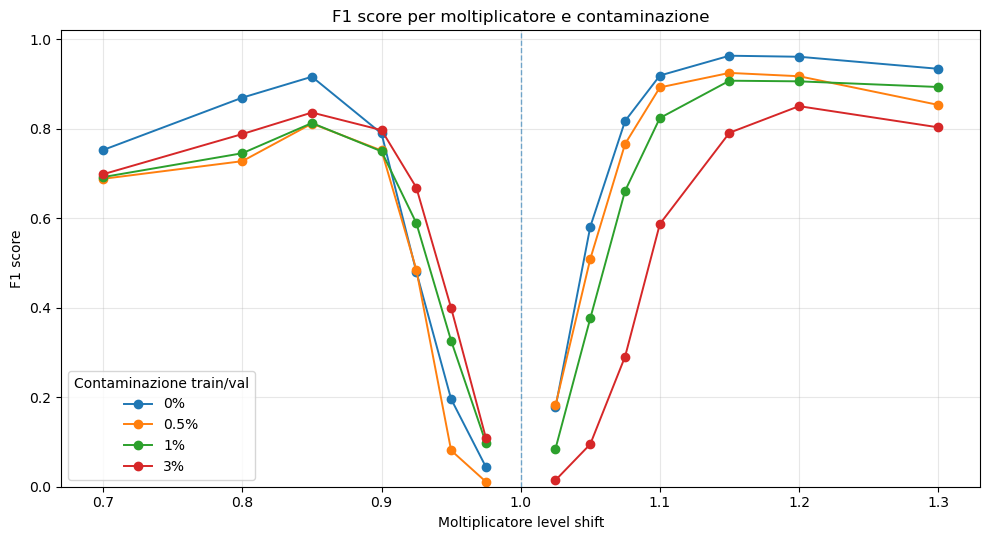

Figura salvata in: C:\Users\ciok4\jupyter file\tesi\artifacts\results\level_shift\contamination_robustness\figures\level_shift_contamination_f1_vs_multiplier_selected.png


In [16]:
# =========================================================
# F1 VS MULTIPLIER BY SELECTED CONTAMINATION LEVELS
# livelli: 0%, 0.5%, 1%, 3%
# una linea per ciascun livello di contaminazione
# la linea viene spezzata tra decrease e increase
# =========================================================

SELECTED_CONTAMINATION_LEVELS = [0, 5, 10, 30]

plot_df = raw_results.copy()

plot_df["contamination_level"] = plot_df["contamination_level"].astype(int)
plot_df["contamination_percent"] = plot_df["contamination_level"] / 10.0
plot_df["multiplier"] = plot_df["multiplier"].astype(float)

plot_df = plot_df[
    plot_df["contamination_level"].isin(SELECTED_CONTAMINATION_LEVELS)
].copy()

# Aggregazione pooled per contamination_level x multiplier
f1_by_mult = (
    plot_df
    .groupby(["contamination_level", "contamination_percent", "multiplier"], as_index=False)
    .agg(
        n_runs=("seed", "count"),
        n_gt_events=("n_gt_events", "sum"),
        n_detected_events=("n_detected_events", "sum"),
        tp=("tp", "sum"),
        fp=("fp", "sum"),
        fn=("fn", "sum"),
    )
)

f1_by_mult["precision_pooled"] = (
    f1_by_mult["tp"] / (f1_by_mult["tp"] + f1_by_mult["fp"])
).replace([np.inf, -np.inf], np.nan)

f1_by_mult["recall_pooled"] = (
    f1_by_mult["tp"] / (f1_by_mult["tp"] + f1_by_mult["fn"])
).replace([np.inf, -np.inf], np.nan)

f1_by_mult["f1_pooled"] = (
    2
    * f1_by_mult["precision_pooled"]
    * f1_by_mult["recall_pooled"]
    / (
        f1_by_mult["precision_pooled"]
        + f1_by_mult["recall_pooled"]
    )
).replace([np.inf, -np.inf], np.nan)

f1_by_mult = (
    f1_by_mult
    .sort_values(["contamination_level", "multiplier"])
    .reset_index(drop=True)
)

display(f1_by_mult.round(4))


# =========================================================
# PLOT
# =========================================================

fig, ax = plt.subplots(figsize=(10, 5.5))

for contamination_level, g in f1_by_mult.groupby("contamination_level"):
    g = g.sort_values("multiplier").copy()

    # Interrompe visivamente la curva tra decrease e increase.
    gap = pd.DataFrame({
        "contamination_level": [contamination_level],
        "contamination_percent": [contamination_level / 10.0],
        "multiplier": [1.0],
        "f1_pooled": [np.nan],
    })

    g_plot = (
        pd.concat([g, gap], ignore_index=True)
        .sort_values("multiplier")
        .reset_index(drop=True)
    )

    ax.plot(
        g_plot["multiplier"],
        g_plot["f1_pooled"],
        marker="o",
        linewidth=1.4,
        label=f"{contamination_level / 10:g}%"
    )

ax.axvline(
    1.0,
    linestyle="--",
    linewidth=1,
    alpha=0.6
)

ax.set_title("F1 score per moltiplicatore e contaminazione")
ax.set_xlabel("Moltiplicatore level shift")
ax.set_ylabel("F1 score")
ax.set_ylim(0, 1.02)
ax.grid(True, alpha=0.3)
ax.legend(title="Contaminazione train/val")

plt.tight_layout()

FIGURE_PATH = FIGURES_DIR / "level_shift_contamination_f1_vs_multiplier_selected.png"
plt.savefig(FIGURE_PATH, dpi=300, bbox_inches="tight")

plt.show()

print("Figura salvata in:", FIGURE_PATH)

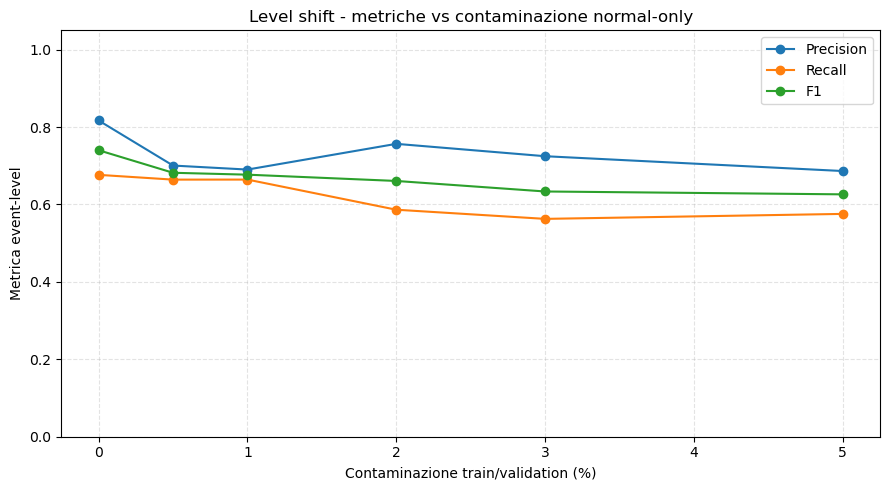

WindowsPath('C:/Users/ciok4/jupyter file/tesi/artifacts/results/level_shift/contamination_robustness/figures/metrics_vs_contamination.png')

In [17]:
# =========================================================
# PLOT: METRICS VS CONTAMINATION
# =========================================================

plot_df = pooled_summary.sort_values("contamination_level").copy()
plot_df["contamination_percent"] = plot_df["contamination_level"] / 10.0

plt.figure(figsize=(9, 5))
plt.plot(plot_df["contamination_percent"], plot_df["precision_pooled"], marker="o", label="Precision")
plt.plot(plot_df["contamination_percent"], plot_df["recall_pooled"], marker="o", label="Recall")
plt.plot(plot_df["contamination_percent"], plot_df["f1_pooled"], marker="o", label="F1")
plt.xlabel("Contaminazione train/validation (%)")
plt.ylabel("Metrica event-level")
plt.title("Level shift - metriche vs contaminazione normal-only")
plt.ylim(0, 1.05)
plt.grid(True, linestyle="--", alpha=0.35)
plt.legend()
plt.tight_layout()

metrics_fig_path = FIGURES_DIR / "metrics_vs_contamination.png"
plt.savefig(metrics_fig_path, dpi=300, bbox_inches="tight")
plt.show()

metrics_fig_path

## File prodotti

Il notebook salva risultati, tabelle e figure nelle cartelle definite in configurazione.

I file principali sono:

- `level_shift_contamination_robustness_raw_double_mad.csv`: risultati per livello e dataset sensitivity;
- `level_shift_contamination_robustness_pooled_double_mad.csv`: tabella pooled principale;
- `level_shift_contamination_threshold_summary_double_mad.csv`: summary delle soglie `double_mad`;
- `level_shift_contamination_by_severity_double_mad.csv`: analisi per severità;
- figure nella cartella `figures/`.

In [18]:
print("RAW_RESULTS_PATH:", RAW_RESULTS_PATH)
print("POOLED_SUMMARY_PATH:", POOLED_SUMMARY_PATH)
print("THRESHOLD_SUMMARY_PATH:", THRESHOLD_SUMMARY_PATH)
print("TRAINING_SUMMARY_PATH:", TRAINING_SUMMARY_PATH)
print("FIGURES_DIR:", FIGURES_DIR)

RAW_RESULTS_PATH: C:\Users\ciok4\jupyter file\tesi\artifacts\results\level_shift\contamination_robustness\level_shift_contamination_robustness_raw_double_mad_code_levels.csv
POOLED_SUMMARY_PATH: C:\Users\ciok4\jupyter file\tesi\artifacts\results\level_shift\contamination_robustness\tables\level_shift_contamination_robustness_pooled_double_mad_code_levels.csv
THRESHOLD_SUMMARY_PATH: C:\Users\ciok4\jupyter file\tesi\artifacts\results\level_shift\contamination_robustness\tables\level_shift_contamination_threshold_summary_double_mad_code_levels.csv
TRAINING_SUMMARY_PATH: C:\Users\ciok4\jupyter file\tesi\artifacts\results\level_shift\contamination_robustness\tables\level_shift_contamination_training_summary_double_mad_code_levels.csv
FIGURES_DIR: C:\Users\ciok4\jupyter file\tesi\artifacts\results\level_shift\contamination_robustness\figures
